In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import scipy.stats 

###introduction
Univariate descriptive = one variable
Multivariate descriptive = two or more variables
its exciting to discover how variables interect with each other....Are they connected? do they affect one another?In short how do they work together?
Before studying relationships between variables, we should always perform univariate analysis on each one.This not only helps us focus our Multivariate analysis but is essential for interpreting how variables relate.

In [2]:
pokemon = pd.read_csv('Pokemon.csv',sep=';')
pokemon.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


CORRELATION = Linear correlation
when studying variables x and y,what happens if x changes? does y change too?In the same direction?By the same amount?

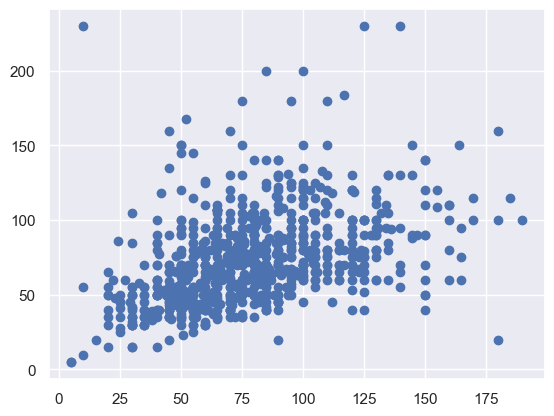

In [3]:
##First step is to plot these varaibles against each other.A scatterplot is perfect for this.
plt.scatter(pokemon["Attack"],pokemon["Defense"])
plt.show()

There are few things to notice....both of the variables are related
-There is a relationship between attack and defense
-this relationship is positive.they move in the same direction
-this relationship looks linear.

The first point is clear from graph...the second uses terminology...positive means they move together...the points follow a line from bottomleft to top right...so if defense is high then attack is high too and vice versa...if defense is low attack is low as well...we can look it in the scaterplot using reg

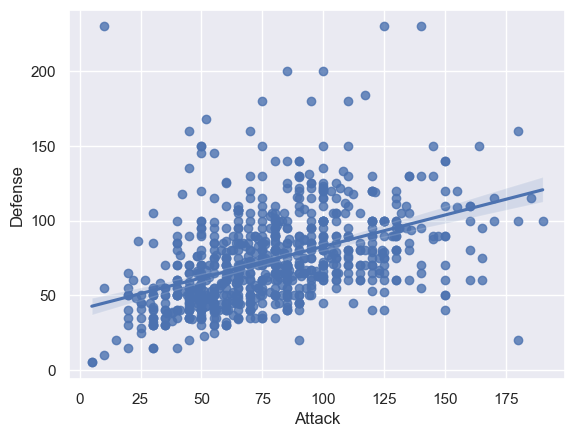

In [4]:
sns.regplot(x="Attack",y="Defense",data=pokemon)
plt.show()

Linear means the relationship roughly follows a straight line.The closer the points are to that line.The stronger the relations
This will be addressed in the numerical section with the correlation coefficition.

If theres no relationship, The scatterplot would look like a random cloud of points with no pattern...the points would spread out in all directions without a trend.No consistent upward or downward movement means cheanges in one variable dont affect the other reliably.

For a non linear relationship,the scatterplot would show a pattern but not straight....points might form a curve,Like ushape or parabola...example- A quandratic relationships show rapid increases or decreases even with a trend,A straight line wouldnot fit well.

Doing this for every pair of variables would be very tedious.Fortunately we can plot all pairs at once....

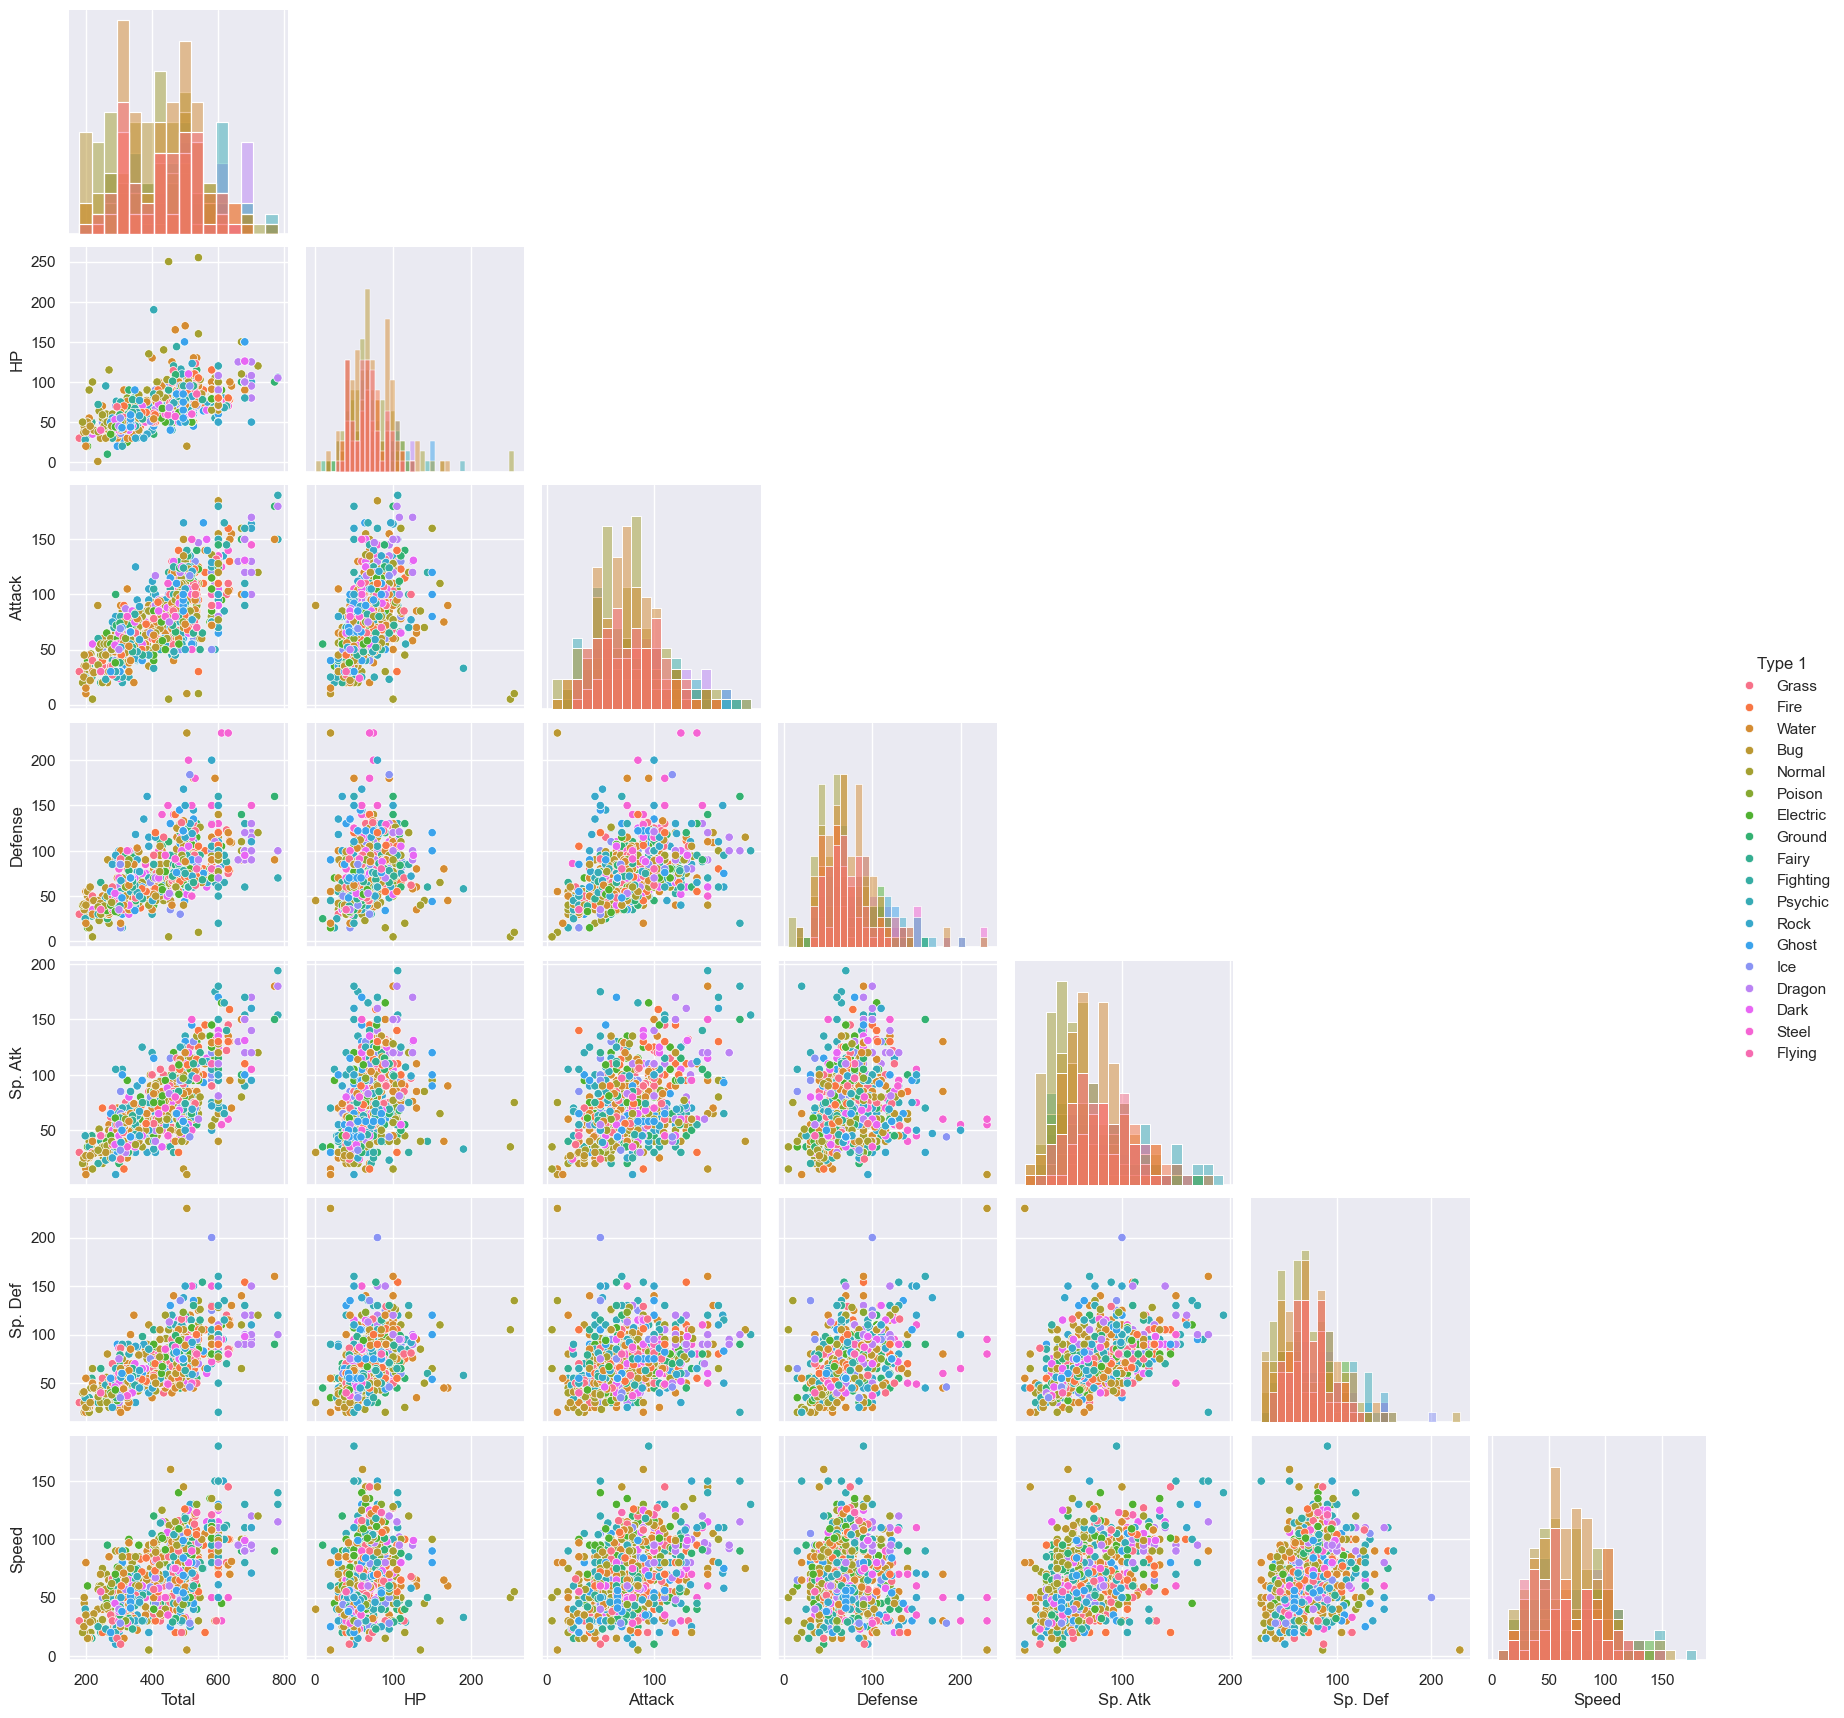

In [11]:
sns.pairplot(pokemon,vars=["Total","HP","Attack","Defense","Sp. Atk","Sp. Def","Speed"],hue="Type 1",corner = True,kind="scatter",diag_kind="hist")
plt.show()

#Distribution

The pairplot shows scatterplot for everypair of variables...vars specifies the columns to include. Hue = "Type 1" colors points by pokemon type..corner = True avoids duplicate plots...kind = "scatter" use scatter plots...and diag_kind = "Hist" puts histograms on diagonal.

#####Correlation == variables are related
#####causaluty == one variable causes other to change

cannot be conclude casuality from correlation alone.

###Numerical
Graphs arenot always clear enough...for example camparing the relationships between sp.atk-speed and total-sp.def...one looks more linear than other...many question arise..stronger relation or isnot linear at all?For this ...we have correlation coefficient...
formula = r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}

	•	x_i = value of X variable
	•	y_i = value of Y variable
	•	\bar{x} = mean of X
	•	\bar{y} = mean of Y
	•	r = correlation coefficient
it calculates== Covariance / (Standard deviation of X × Standard deviation of Y)

simple example---

hours studied               marks 
2                              50
4                              60
6                              70
8                              80
As hours increase, marks increase → positive correlation
so correlation r = 0.98...Very strong relationship...the correlation coefficiant shows how much these variables change in sync...but correlations only measure linear relation..nonnlinear relation cant be capture by it.


In [12]:
pokemon.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [27]:
#correlation mattrix
pokemon_new = pokemon.drop(columns=["Name","Type 1","Type 2"])

In [29]:
pokemon_new1=pokemon_new.drop(columns="#")
corrMatrix=pokemon_new1.corr()
corrMatrix

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
Total,1.000000,0.618748,0.736211,0.612787,0.747250,0.717609,0.575943,0.048384,0.501758
HP,0.618748,1.000000,0.422386,0.239622,0.362380,0.378718,0.175952,0.058683,0.273620
Attack,0.736211,0.422386,1.000000,0.438687,0.396362,0.263990,0.381240,0.051451,0.345408
Defense,0.612787,0.239622,0.438687,1.000000,0.223549,0.510747,0.015227,0.042419,0.246377
Sp. Atk,0.747250,0.362380,0.396362,0.223549,1.000000,0.506121,0.473018,0.036437,0.448907
Sp. Def,0.717609,0.378718,0.263990,0.510747,0.506121,1.000000,0.259133,0.028486,0.363937
Speed,0.575943,0.175952,0.381240,0.015227,0.473018,0.259133,1.000000,-0.023121,0.326715
Generation,0.048384,0.058683,0.051451,0.042419,0.036437,0.028486,-0.023121,1.000000,0.079794
Legendary,0.501758,0.273620,0.345408,0.246377,0.448907,0.363937,0.326715,0.079794,1.000000


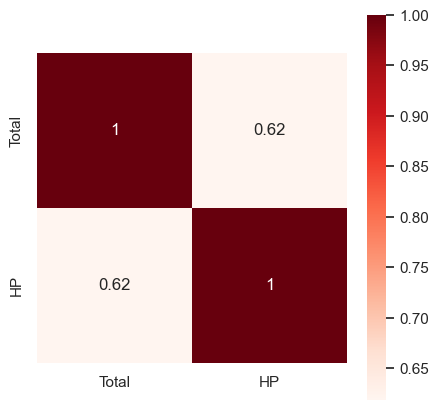

In [30]:
#also possible to only calculate the correlation of two variables...
plt.figure(figsize=(5,5))
fig=sns.heatmap(pokemon_new1[["Total","HP"]].corr(),annot=True,square=True,cmap="Reds")
plt.show()

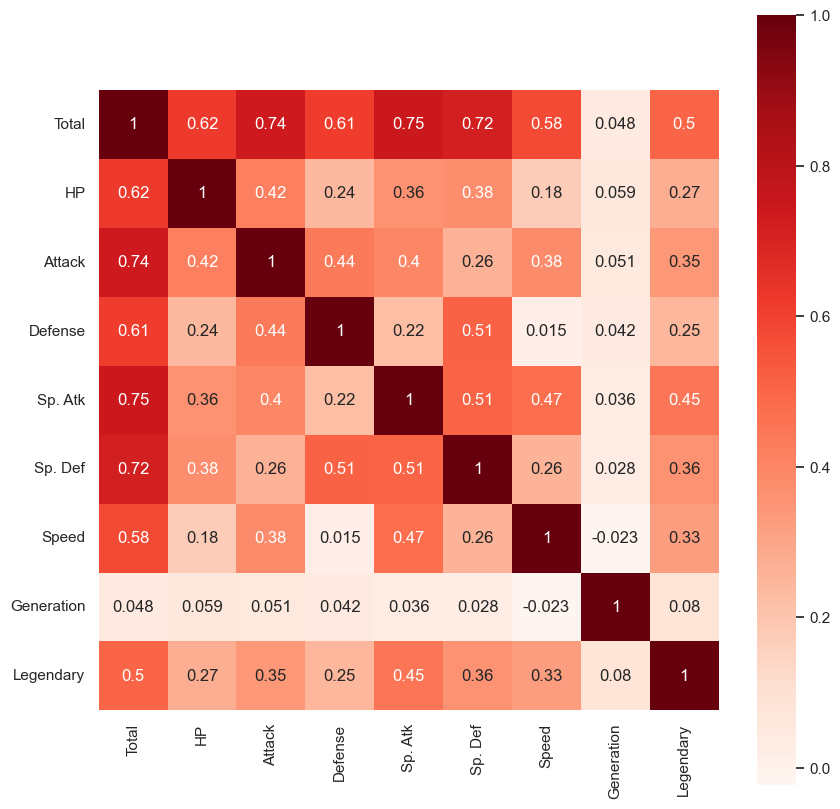

In [31]:
#Handier to have the correlations of all variables among each other represented in 1 measure.
plt.figure(figsize=(10,10))
fig=sns.heatmap(corrMatrix,annot=True,square=True,cmap="Reds")
plt.show()

The heatmap visualizes the correlation mattrix...annot=true displays correlation values...square=true makes cells square...cmao="red" uses shades of blue...some facts..
-correlation coefficient always ranges from -1 to 1 means no linears correlations...
-1 means perfect positive correlations...
-1 means perfect negative linear correlations...
-Total has high correlations with all stats...this makes sense since total is the sum of all stats
in real data perfect correlations (0 or +-1) are rare in real data

###Association
what if one variable is categorical?...correlation desnot apply cuz correlation only works for two numerical variables...
For that we have ASSOCIATION

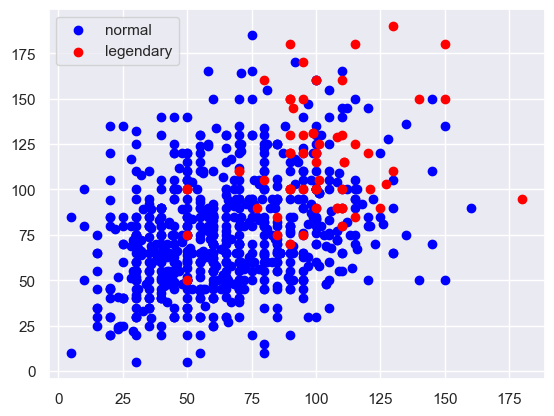

In [ ]:
plt.scatter(pokemon.loc[~pokemon["Legendary"],"Speed"],pokemon.loc[~pokemon["Legendary"],"Attack"],color="Blue",label="normal")#~pokemon["Legendary"] mean boolean...this selects non legendary ...pick those with false or non legendary
plt.scatter(pokemon.loc[pokemon["Legendary"],"Speed"],pokemon.loc[pokemon["Legendary"],"Attack"],color="red",label="legendary")
plt.legend()
plt.show()

Its important interpret graphs to decide which associations are woth investigation.